# Notebook 03 — Matrices and Matrix Multiplication

**Module:** 04 — Linear Algebra  
**Notebook:** 03 of 10  
**Prerequisites:** NB02  
**Time estimate:** 60 minutes

---
## Step 1 — Motivation

Matrix multiplication is at the heart of PCA, regression, neural networks, and
graph analysis. Understanding *what matrix multiplication computes* — not just
how to call `@` — is what lets you debug a broken PCA pipeline or understand
why a matrix is singular.

---
## Step 2 — Intuition

**Matrix multiplication as a sequence of dot products:**
$C = AB$, where $C_{ij} = \mathbf{a}_{i,:} \cdot \mathbf{b}_{:,j}$ — the $i$-th row of
$A$ dotted with the $j$-th column of $B$.

**Matrix as a linear transformation:**
Multiplying a vector $\mathbf{x}$ by matrix $A$ transforms it: $A\mathbf{x}$ is a
new vector. A $2\times 2$ matrix rotates, scales, and/or shears 2D space.

**Inverse and singular matrices:**
If $A^{-1}$ exists, $A^{-1}A = I$ (identity). Singular matrices have no inverse —
they collapse some dimension of the input to zero (information is lost).

---
## Step 3 — Biological Background

**Matrix multiplication in transcription factor binding:**
- Let $T \in \mathbb{R}^{G \times F}$ be a gene-TF binding matrix ($T_{gf} = 1$ if
  TF $f$ binds gene $g$'s promoter).
- Let $\mathbf{e} \in \mathbb{R}^F$ be TF expression levels.
- Then $T\mathbf{e} \in \mathbb{R}^G$ gives predicted gene expression — a direct
  matrix-vector product.

**Position weight matrices (PWM):**
The score of a DNA sequence $s$ against a PWM $M$ is computed via a sum
equivalent to a dot product — matrix multiplication underlies sequence motif scanning.

---
## Step 4 — Mathematical Explanation

**Matrix multiplication:** $(AB)_{ij} = \sum_k A_{ik} B_{kj}$.
Requires inner dimensions to match: $(m \times k)(k \times n) = (m \times n)$.

**Transpose:** $(A^\top)_{ij} = A_{ji}$. Key identities:
- $(AB)^\top = B^\top A^\top$
- $(A^\top)^\top = A$
- For symmetric matrix: $A^\top = A$ (covariance matrices are always symmetric)

**Inverse:** $A^{-1}$ exists iff $\det(A) \neq 0$ iff $A$ is full rank.
$AA^{-1} = A^{-1}A = I$.

**The four fundamental subspaces of $A \in \mathbb{R}^{m \times n}$:**
- Column space: span of columns — what outputs are reachable?
- Null space: $\{\mathbf{x}: A\mathbf{x}=\mathbf{0}\}$ — what inputs map to zero?
- Row space and left null space (transposed versions).
- $\text{rank}(A) = \dim(\text{column space}) = \dim(\text{row space})$

---
## Step 6 — Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cell 6.1 — Matrix multiplication from scratch vs. NumPy
def matmul_scratch(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Matrix multiplication via nested loops — for understanding, not speed."""
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, f"Inner dimensions must match: {k} != {k2}"
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for p in range(k):
                C[i, j] += A[i, p] * B[p, j]
    return C

rng = np.random.default_rng(42)
A = rng.integers(0, 5, (3, 4)).astype(float)
B = rng.integers(0, 5, (4, 2)).astype(float)

C_scratch = matmul_scratch(A, B)
C_numpy   = A @ B

print("A =\n", A)
print("\nB =\n", B)
print("\nAB (scratch) =\n", C_scratch)
print("\nAB (NumPy @) =\n", C_numpy)
print(f"\nMax difference: {np.max(np.abs(C_scratch - C_numpy)):.2e}")

A =
 [[0. 3. 3. 2.]
 [2. 4. 0. 3.]
 [1. 0. 2. 4.]]

B =
 [[3. 3.]
 [3. 3.]
 [2. 0.]
 [4. 2.]]

AB (scratch) =
 [[23. 13.]
 [30. 24.]
 [23. 11.]]

AB (NumPy @) =
 [[23. 13.]
 [30. 24.]
 [23. 11.]]

Max difference: 0.00e+00


In [3]:
# Cell 6.2 — Key matrix properties: transpose, inverse, solving Ax=b

# Symmetric matrix example: gene covariance
n = 5
X_toy = rng.normal(0, 1, (n, 20))
Cov = (X_toy @ X_toy.T) / 19
print(f"Cov is symmetric: {np.allclose(Cov, Cov.T)}")
print(f"Cov shape: {Cov.shape}")

# Matrix inverse and solving a linear system
A_sq = rng.normal(0, 1, (4, 4))
b_vec = rng.normal(0, 1, 4)

# Method 1: inverse (numerically unstable for large matrices)
x_inv = np.linalg.inv(A_sq) @ b_vec
# Method 2: solve (preferred — uses LU decomposition)
x_solve = np.linalg.solve(A_sq, b_vec)

print(f"\nSolving Ax=b:")
print(f"  x via inverse: {x_inv.round(4)}")
print(f"  x via solve:   {x_solve.round(4)}")
print(f"  Residual ‖Ax-b‖: {np.linalg.norm(A_sq @ x_solve - b_vec):.2e}")

# Rank and determinant
print(f"\nRank: {np.linalg.matrix_rank(A_sq)}")
print(f"Det:  {np.linalg.det(A_sq):.4f}")

Cov is symmetric: True
Cov shape: (5, 5)

Solving Ax=b:
  x via inverse: [-1.6047  1.0412 -2.2029 -0.4177]
  x via solve:   [-1.6047  1.0412 -2.2029 -0.4177]
  Residual ‖Ax-b‖: 1.57e-16

Rank: 4
Det:  2.0820


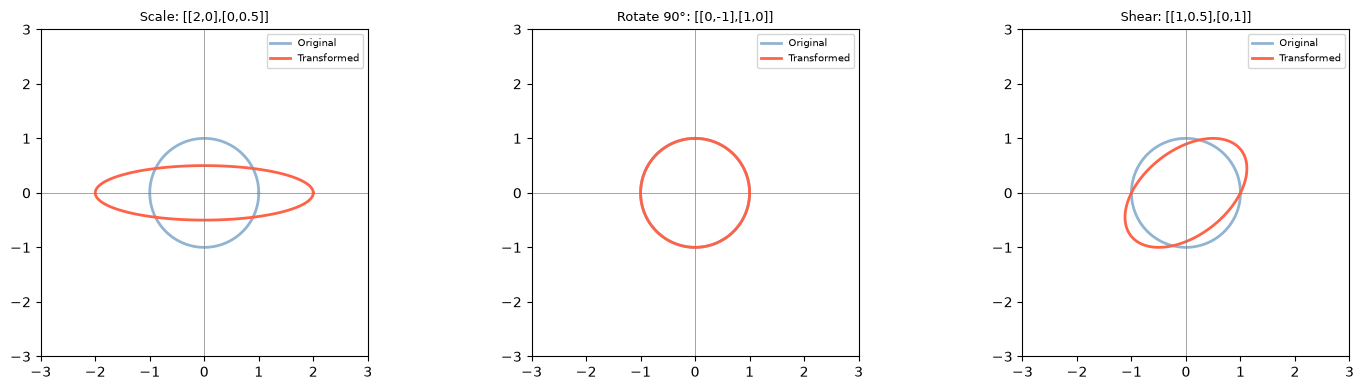

In [4]:
# Cell 6.3 — Matrix as linear transformation: visualize what a 2x2 matrix does
# Biological analogy: rotating from gene space to PC space

# Grid of 2D points (genes in 2-sample space)
theta_vals = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta_vals), np.sin(theta_vals)])  # unit circle

# Three transformation matrices
T_scale    = np.array([[2, 0], [0, 0.5]])    # stretch x by 2, compress y
T_rotate   = np.array([[0, -1], [1, 0]])      # 90° rotation
T_shear    = np.array([[1, 0.5], [0, 1]])     # shear

transforms = [
    (T_scale,  "Scale: [[2,0],[0,0.5]]"),
    (T_rotate, "Rotate 90°: [[0,-1],[1,0]]"),
    (T_shear,  "Shear: [[1,0.5],[0,1]]")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (T, label) in zip(axes, transforms):
    transformed = T @ circle
    ax.plot(*circle, 'steelblue', lw=2, label='Original', alpha=0.6)
    ax.plot(*transformed, 'tomato', lw=2, label='Transformed')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal'); ax.axhline(0, lw=0.5, color='gray'); ax.axvline(0, lw=0.5, color='gray')
    ax.set_title(label, fontsize=9); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

---
## Step 8 — Exercises

1. Implement `matmul_scratch(A, B)`. What is its time complexity in terms of matrix
   dimensions $m, k, n$? Why does NumPy's `@` use BLAS instead of nested loops?
2. Compute $(AB)^\top$ and $B^\top A^\top$ for matrices A=(3×4) and B=(4×2).
   Verify they are equal.
3. Generate a singular matrix (rank < min dimensions). Verify `np.linalg.det ≈ 0`
   and that `np.linalg.solve` raises an error (or gives a very large solution).
4. The TF-gene binding matrix $T \in \{0,1\}^{G \times F}$. If $\mathbf{e}$ is the
   TF expression vector, what does $(T^\top T)_{ff'}$ represent biologically?

---
## Quiz — Active Recall

1. What are the dimension requirements for matrix multiplication $AB$?
2. What does $(AB)^\top = B^\top A^\top$ mean? Why does the order reverse?
3. When does a matrix inverse exist? What happens when you try to invert a singular matrix?
4. What is the null space of a matrix? Give a biological example of a matrix with
   a non-trivial null space.
5. Why is `np.linalg.solve(A, b)` preferred over `np.linalg.inv(A) @ b`?

---
## Reflection

**Date completed:** ____________________

> *[Can you explain matrix multiplication as a sequence of dot products? Can you draw what a 2×2 matrix does to the unit circle?]*

---
*Next: `04_eigenvalues_and_eigenvectors.ipynb`*